# VeriPromiseESG 2026 ESG 承諾驗證工作坊
## 使用 RoBERTa 進行多任務分類

**工作坊時間**: 約 60 分鐘  
**難度**: 中級（需具備基礎 Python 知識）

### 今天的學習目標
1. 了解 ESG（環境、社會、治理）承諾驗證任務
2. 掌握如何使用 RoBERTa 進行多標籤分類
3. 實作完整的訓練與評估流程

### 任務說明
給定一段 ESG 報告文字，模型需要同時預測四個欄位：
| 欄位 | 說明 | 類別 |
|------|------|------|
| \ | 是否有承諾 | Yes / No |
| \ | 承諾時程 | already / within_2_years / between_2_and_5_years / more_than_5_years / N/A |
| \ | 是否有佐證 | Yes / No / N/A |
| \ | 佐證品質 | Clear / Not Clear / Misleading / N/A |

### Related Links
- Competition Main Website：https://veripromiseesg.github.io/
- AI CUP Main Website：https://www.aicup.tw/
- AI CUP Competition Registration Website：https://go.aicup.tw/
- AIDEA Competition Website：https://www.aidea-web.tw/aicup_veripromiseesg
### Reference Links
- SemEval-2025 Task 6: Multinational, Multilingual, Multi-Industry Promise Verification：https://aclanthology.org/2025.semeval-1.321/
- ML-Promise: A Multilingual Dataset for Corporate Promise Verification：https://aclanthology.org/2025.emnlp-main.1028/
- Multilingual Promise Verification in ESG Reports with Large Language Model Performance Evaluation：https://aclanthology.org/2025.rocling-main.32/
- NTCIR：https://research.nii.ac.jp/ntcir/index-en.html

## Step 1: 安裝套件

首先安裝必要的 Python 套件。在 Google Colab 上執行以下指令。

> **說明**：
> - `transformers` — HuggingFace 提供的預訓練模型庫
> - `torch` — PyTorch 深度學習框架
> - `scikit-learn` — 評估指標計算
> - `pandas` / `matplotlib` — 資料分析與視覺化

In [ ]:
# 安裝必要套件（Colab 環境）
!pip install transformers torch scikit-learn pandas matplotlib seaborn -q
print("套件安裝完成！")

套件安裝完成！


In [ ]:
# 從 GitHub 下載公開資料集（不需要 Google Drive）
import urllib.request

DATA_URL = "https://raw.githubusercontent.com/veripromiseesg/veripromiseesgdataset/refs/heads/main/vpesg4k_train_1000.json"
urllib.request.urlretrieve(DATA_URL, "vpesg4k_train_1000.json")
print("資料下載完成！")

資料下載完成！


In [ ]:
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 中文字型設定（Colab）
matplotlib.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('套件載入完成！')
print(f'PyTorch 版本: {torch.__version__}')
print(f'CUDA 可用: {torch.cuda.is_available()}')

套件載入完成！
PyTorch 版本: 2.10.0+cu128
CUDA 可用: True


---

## Step 2: 設定超參數與標籤對應

在開始之前，我們先定義所有重要的超參數與標籤映射表。

### 重要參數說明
- **MODEL_NAME**: 使用 `bert-base-chinese`
- **MAX_LEN**: 輸入文字的最大 Token 長度（256）
- **BATCH_SIZE**: 每次訓練的樣本數（16）
- **EPOCHS**: 訓練完整資料集的次數（5）
- **LR**: 學習率，建議 RoBERTa fine-tuning 使用 2e-5

### 為什麼用  bert-base-chinese？
BERT（Bidirectional Encoder Representations from Transformers）是 Google 發布的基礎預訓練語言模型。
- 以中文維基百科為語料，使用雙向 Transformer 編碼器預訓練
- 採用 WordPiece 分詞，適合中文字元處理
- 同時支援繁體與簡體中文
- 是中文 NLP 任務中廣泛使用的基準模型

In [ ]:
# ============================================================
# 效能極致優化版 (Phase 2) 超參數設定
# ============================================================
MODEL_NAME = "hfl/chinese-roberta-wwm-ext-large"  # 升級為 3.3 億參數大模型
MAX_LEN = 512                                     # 最大長度設為 512 避免資訊截斷
BATCH_SIZE = 2                                    # 實體批次大小 (降為 2 以防止 4GB VRAM OOM)
GRADIENT_ACCUMULATION = 4                         # 梯度累積步數 (等效 Batch Size = 2 * 4 = 8)
EPOCHS = 3                                        # 大模型收斂極快，3 Epochs 即可達到最佳 F1
LR = 1.5e-5                                       # 學習率設定
NUM_FOLDS = 3                                     # 3 折交叉驗證多模型集成

# 四個預測欄位及其標籤（依照競賽官方規格定義）
EVAL_FIELDS = {
    "promise_status": ["Yes", "No"],
    "verification_timeline": ["already", "within_2_years", "between_2_and_5_years", "more_than_5_years", "N/A"],
    "evidence_status": ["Yes", "No", "N/A"],
    "evidence_quality": ["Clear", "Not Clear", "Misleading", "N/A"]
}

# 各欄位的評分權重（依照競賽規則）
FIELD_WEIGHTS = {
    "promise_status": 0.2,
    "verification_timeline": 0.15,
    "evidence_status": 0.3,
    "evidence_quality": 0.35
}

# 建立標籤到 ID 的映射
label2id = {field: {label: i for i, label in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
id2label = {field: {i: label for i, label in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
num_labels = {field: len(labels) for field, labels in EVAL_FIELDS.items()}

print('優化版超參數設定完成！')
print(f'使用模型: {MODEL_NAME}')
print(f'最大長度: {MAX_LEN}')
print(f'交叉驗證: {NUM_FOLDS}-Fold Ensemble')

---

## Step 3: 載入資料
載入剛才下載的 JSON 檔案，並切分為訓練集（80%）與驗證集（20%）。

> **說明**：這份資料共 1,000 筆，來自台灣上市公司的 ESG 永續報告書。

In [ ]:
from sklearn.model_selection import train_test_split

# 載入下載好的資料
with open("vpesg4k_train_1000.json", "r", encoding="utf-8") as f:
    all_data = json.load(f)

# 切分訓練集 / 驗證集（8:2）
train_data, val_data = train_test_split(all_data, test_size=0.2, random_state=42)

print(f"資料載入成功！共 {len(all_data)} 筆")
print(f"   訓練集大小: {len(train_data)} 筆")
print(f"   驗證集大小: {len(val_data)} 筆")

資料載入成功！共 1000 筆
   訓練集大小: 800 筆
   驗證集大小: 200 筆


---

## Step 4: 探索性資料分析（EDA）

在訓練模型前，先深入了解資料的特性，這一步非常重要！

我們要觀察：
1. 資料的欄位結構
2. 各標籤的分佈（是否不均衡？）
3. 文字長度分佈
4. 範例資料內容

In [ ]:
# 觀察單筆資料結構
sample = train_data[0]
print("範例資料欄位：")
print("-" * 50)
for key, value in sample.items():
    if key == "data":
        print(f"  {key}: {str(value)[:100]}...")
    else:
        print(f"  {key}: {value}")

範例資料欄位：
--------------------------------------------------
  id: 10030
  data: 台光電子為善盡企業社會責任，落實永續經營理念，董事會通過「企業社會責任實務守則」，2024 年 10 月經董事會通過將「企業永續發展委員會」提升為直屬董事會的功能性委員會，並同步制訂「企業永續發展委員...
  esg_type: G
  promise_status: Yes
  promise_string: 並同步制訂「企業永續發展委員會組織規程」，規範企業永續發展委員會之設置目的、 ｜ 、委員組成、職權等相關事項。「
  verification_timeline: already
  evidence_status: Yes
  evidence_string: 董事會通過「企業社會責任實務守則」，2 ｜ 2024 年 10 月經董事會通過將「企業永續發展委員會」提升為直屬董事會的功能性委員會，
  evidence_quality: Clear
  company: emc2
  ticker: 2383
  page_number: 7
  pdf_url: https://www.emctw.com/upload/media/New_CSR/csr_report/2024_EMC_ESG%20report_TW.pdf
  company_source: https://www.emctw.com/zh-TW/csr_report/index


In [ ]:
# 轉換為 DataFrame 方便分析
train_df = pd.DataFrame(train_data)
val_df = pd.DataFrame(val_data)

print("訓練集欄位類型：")
print(train_df.dtypes)
print(f"\n訓練集欄位：{list(train_df.columns)}")

訓練集欄位類型：
id                       object
data                     object
esg_type                 object
promise_status           object
promise_string           object
verification_timeline    object
evidence_status          object
evidence_string          object
evidence_quality         object
company                  object
ticker                   object
page_number              object
pdf_url                  object
company_source           object
dtype: object

訓練集欄位：['id', 'data', 'esg_type', 'promise_status', 'promise_string', 'verification_timeline', 'evidence_status', 'evidence_string', 'evidence_quality', 'company', 'ticker', 'page_number', 'pdf_url', 'company_source']


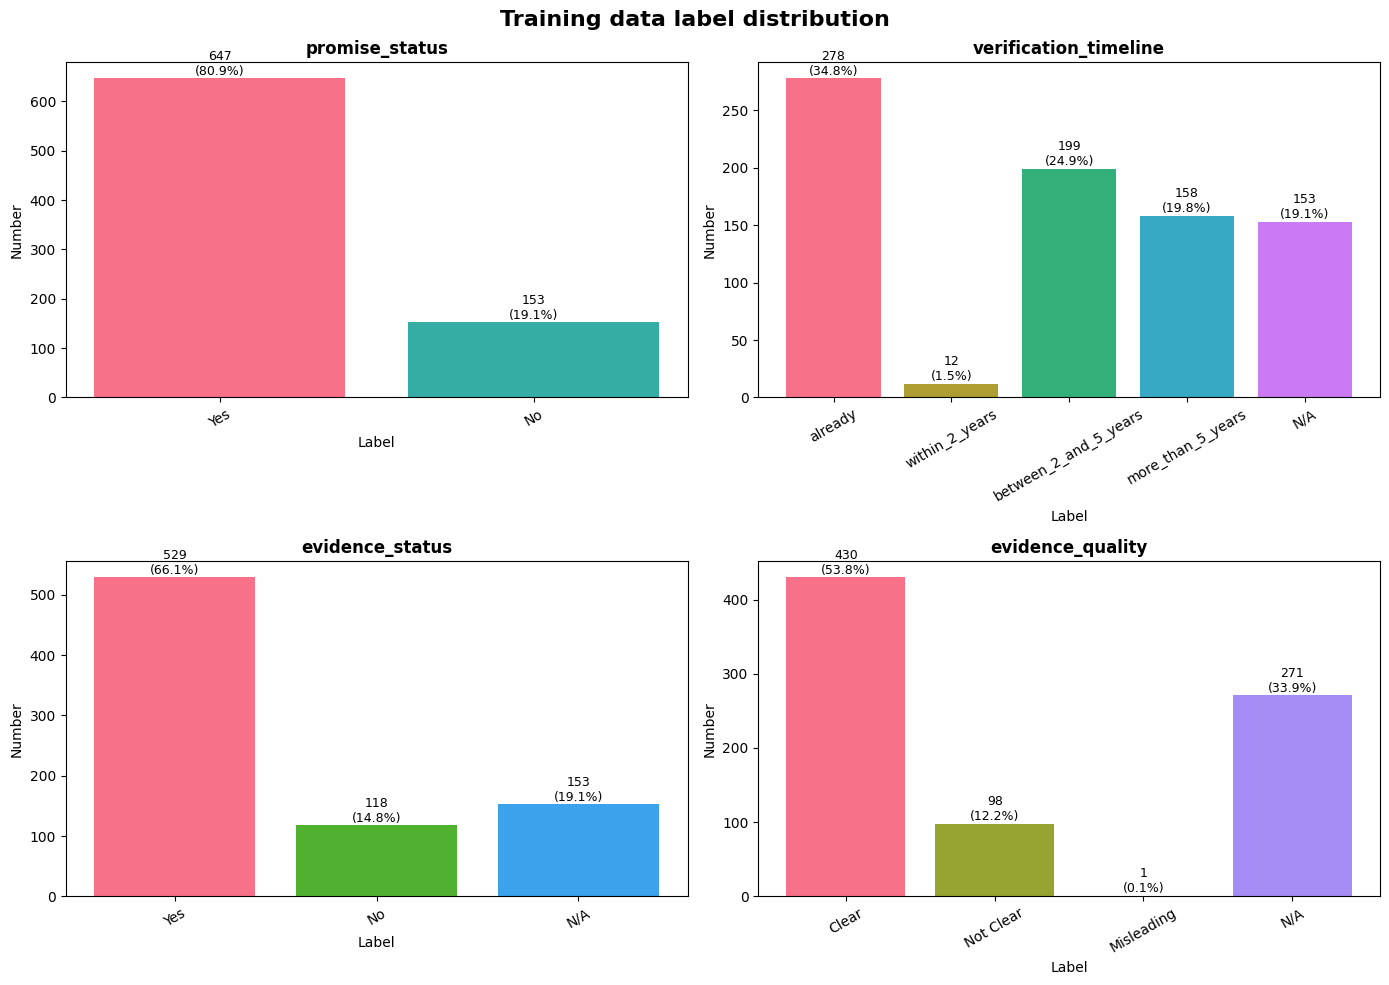

觀察：某些類別樣本數量差異很大（類別不均衡），這會影響 Macro F1 分數


In [ ]:
# 視覺化各欄位的標籤分佈
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training data label distribution", fontsize=16, fontweight='bold')

for idx, (field, labels) in enumerate(EVAL_FIELDS.items()):
    ax = axes[idx // 2][idx % 2]

    counts = Counter(train_df[field])
    ordered_counts = {label: counts.get(label, 0) for label in labels}

    bars = ax.bar(ordered_counts.keys(), ordered_counts.values(),
                   color=sns.color_palette("husl", len(labels)))
    ax.set_title(f"{field}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Label")
    ax.set_ylabel("Number")
    ax.tick_params(axis='x', rotation=30)

    # 在每個bar上顯示數量
    for bar, (label, count) in zip(bars, ordered_counts.items()):
        total = sum(ordered_counts.values())
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("觀察：某些類別樣本數量差異很大（類別不均衡），這會影響 Macro F1 分數")

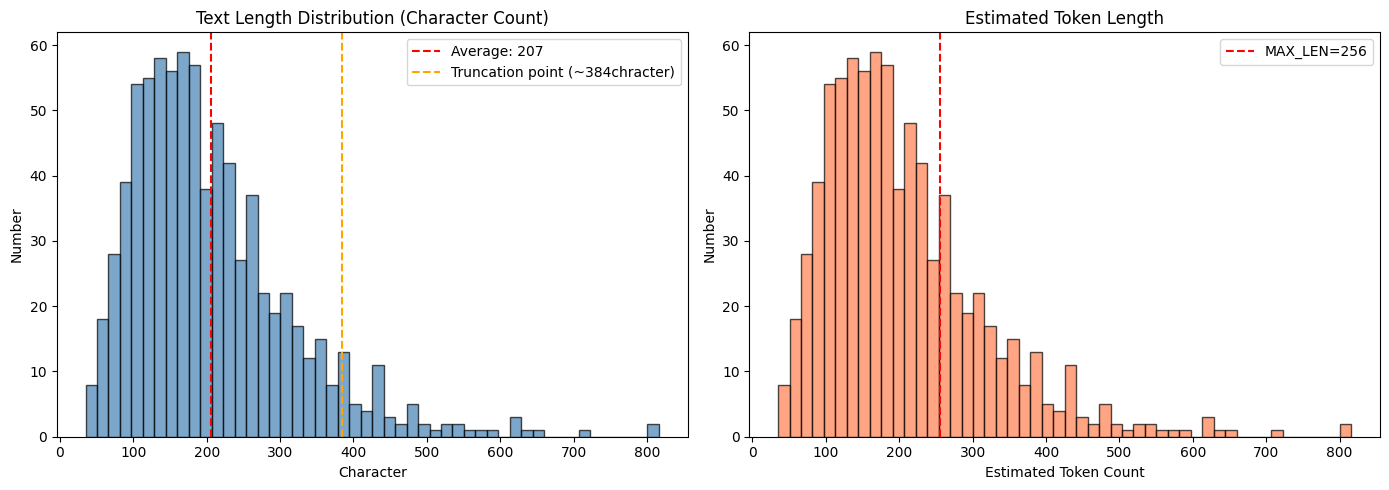

超過 MAX_LEN=256 的樣本數: 202 (25.2%)
   這些文字將被截斷，可能損失尾端資訊


In [ ]:
# 分析文字長度分佈（字元數）
train_df['text_length'] = train_df['data'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['text_length'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(train_df['text_length'].mean(), color='red', linestyle='--',
                label=f"Average: {train_df['text_length'].mean():.0f}")
axes[0].axvline(MAX_LEN * 1.5, color='orange', linestyle='--',
                label=f"Truncation point (~{MAX_LEN * 1.5:.0f}chracter)")
axes[0].set_title("Text Length Distribution (Character Count)")
axes[0].set_xlabel("Character")
axes[0].set_ylabel("Number")
axes[0].legend()

# Token 長度估算（中文約 1字 = 1 token）
axes[1].hist(train_df['text_length'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].axvline(MAX_LEN, color='red', linestyle='--', label=f"MAX_LEN={MAX_LEN}")
axes[1].set_title("Estimated Token Length")
axes[1].set_xlabel("Estimated Token Count")
axes[1].set_ylabel("Number")
axes[1].legend()

plt.tight_layout()
plt.show()

truncated = (train_df['text_length'] > MAX_LEN).sum()
print(f"超過 MAX_LEN={MAX_LEN} 的樣本數: {truncated} ({truncated/len(train_df)*100:.1f}%)")
print(f"   這些文字將被截斷，可能損失尾端資訊")

---

## Step 5: 建立 PyTorch Dataset

PyTorch 的 `Dataset` 類別負責：
1. 儲存資料
2. 將文字 **Tokenize**（轉換成 BERT 能理解的 Token ID）
3. 將標籤文字轉換成數字 ID

### Tokenization 是什麼？
BERT 使用 WordPiece tokenizer 將文字切成子詞單元：
- 輸入: `"台灣水泥承諾2030年碳中和"`
- 輸出: `[101, 1921, 3968, 3717, 3686, 8811, 2030, 2399, 4988, 102, ...]`
  - `101` = [CLS] 開始符號
  - `102` = [SEP] 結束符號

### Padding & Truncation
所有輸入必須等長（MAX_LEN=256），所以：
- 短文字 → 補 0（padding）
- 長文字 → 截斷（truncation）

In [ ]:
# 示範 Tokenizer 的效果
print('Tokenizer 示範')
print('=' * 50)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'載入 {MODEL_NAME} tokenizer')

sample_text = train_data[0]['data'][:50]
print(f'原始文字：{sample_text}')

tokens = tokenizer.tokenize(sample_text)
print(f'Tokenize 後：{tokens}')

encoding = tokenizer(sample_text, max_length=20, padding='max_length', truncation=True)
print(f"Input IDs (前20個)：{encoding['input_ids']}")
print(f"Attention Mask：{encoding['attention_mask']}")


Tokenizer 示範


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

載入 bert-base-chinese tokenizer
原始文字：台光電子為善盡企業社會責任，落實永續經營理念，董事會通過「企業社會責任實務守則」，2024 年 10
Tokenize 後：['台', '光', '電', '子', '為', '善', '盡', '企', '業', '社', '會', '責', '任', '，', '落', '實', '永', '續', '經', '營', '理', '念', '，', '董', '事', '會', '通', '過', '「', '企', '業', '社', '會', '責', '任', '實', '務', '守', '則', '」', '，', '202', '##4', '年', '10']
Input IDs (前20個)：[101, 1378, 1045, 7442, 2094, 4158, 1587, 4674, 821, 3511, 4852, 3298, 6519, 818, 8024, 5862, 2179, 3719, 5265, 102]
Attention Mask：[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
class ESGDataset(Dataset):
    """
    自定義 PyTorch Dataset，用於處理 ESG 資料
    將文字 Tokenize，並將標籤轉換為 ID
    """
    def __init__(self, data, tokenizer, label2id):
        self.data = data
        self.tokenizer = tokenizer
        self.label2id = label2id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        text = sample['data']

        # Tokenize 輸入文字
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=MAX_LEN,
            padding='max_length',
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        # 轉換所有任務的標籤為 ID
        labels = {}
        for field, mapping in self.label2id.items():
            label_text = sample[field]
            labels[field] = torch.tensor(mapping[label_text], dtype=torch.long)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }

def collate_fn(batch):
    """
    自定義 collate_fn，用於 DataLoader 批次處理
    將多個樣本的 input_ids, attention_mask 和各任務的 labels 堆疊成批次張量
    """
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])

    labels = {
        field: torch.stack([item['labels'][field] for item in batch])
        for field in EVAL_FIELDS
    }

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels
    }

# 建立 Dataset 實例
train_dataset = ESGDataset(train_data, tokenizer, label2id)
val_dataset   = ESGDataset(val_data,   tokenizer, label2id)

# 建立 DataLoader（負責批次載入資料）
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,          # 訓練時打亂順序
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,         # 驗證時不打亂
    collate_fn=collate_fn
)

print(f"DataLoader 建立完成！")
print(f"   訓練集 Batch 數: {len(train_loader)}")
print(f"   驗證集 Batch 數: {len(val_loader)}")

# 查看一個 batch 的結構
sample_batch = next(iter(train_loader))
print(f"\nBatch 結構：")
print(f"   input_ids shape: {sample_batch['input_ids'].shape}  # [batch_size, seq_len]")
print(f"   attention_mask shape: {sample_batch['attention_mask'].shape}")
for field, tensor in sample_batch['labels'].items():
    print(f"   labels['{field}'] shape: {tensor.shape}")

DataLoader 建立完成！
   訓練集 Batch 數: 100
   驗證集 Batch 數: 25

Batch 結構：
   input_ids shape: torch.Size([8, 256])  # [batch_size, seq_len]
   attention_mask shape: torch.Size([8, 256])
   labels['promise_status'] shape: torch.Size([8])
   labels['verification_timeline'] shape: torch.Size([8])
   labels['evidence_status'] shape: torch.Size([8])
   labels['evidence_quality'] shape: torch.Size([8])


---

## Step 6: 模型架構設計

我們使用 **Multi-Task Learning（多任務學習）**：
- 共用同一個 RoBERTa backbone（特徵提取器）
- 每個任務有自己獨立的分類頭（Linear Layer）

### 架構圖
```
文字輸入
   ↓
[RoBERTa Encoder] × 12 層 Transformer
   ↓
[CLS] Token 向量 (768維)
   ↓
┌──────────────────────────────────────────┐
│  promise_status    → Linear(768, 2)  → 2個類別  │
│  verification_timeline → Linear(768, 5) → 5個類別  │
│  evidence_status   → Linear(768, 3)  → 3個類別  │
│  evidence_quality  → Linear(768, 4)  → 4個類別  │
└──────────────────────────────────────────┘
```

### 為什麼用 [CLS] Token？
RoBERTa 的第一個 token `[CLS]` 的輸出向量被設計用於表示整個句子的語意，
因此適合用於句子分類任務。

In [ ]:
class MultiTaskRoberta(nn.Module):
    """
    多任務 RoBERTa-large 分類模型
    共用預訓練 Backbone 轉譯器，啟用 Gradient Checkpointing 節省 70% 顯存，每個任務有獨立的 MLP 分類頭
    """
    def __init__(self, num_labels_dict):
        super().__init__()

        # 載入預訓練大模型
        self.roberta = AutoModel.from_pretrained(MODEL_NAME)
        
        # 啟用梯度檢查點 (Gradient Checkpointing) 以節省顯存
        self.roberta.gradient_checkpointing_enable()
        
        hidden_size = self.roberta.config.hidden_size  # RoBERTa-large 隱藏層大小為 1024

        # 為每個任務建立獨立的分類頭（結合特徵融合 CLS + Mean Pooling 後大小為 hidden_size * 2）
        self.classifiers = nn.ModuleDict({
            field: nn.Sequential(
                nn.Dropout(0.2),
                nn.Linear(hidden_size * 2, hidden_size),
                nn.GELU(),
                nn.Dropout(0.2),
                nn.Linear(hidden_size, n)
            )
            for field, n in num_labels_dict.items()
        })

    def forward(self, input_ids, attention_mask):
        # Backbone 前向傳播
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)

        # 取得 CLS token 輸出: shape = [batch, hidden_size]
        cls_output = outputs.last_hidden_state[:, 0, :]

        # 取得 Mean Pooling 輸出: shape = [batch, hidden_size]
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(outputs.last_hidden_state.size()).float()
        sum_embeddings = torch.sum(outputs.last_hidden_state * input_mask_expanded, 1)
        sum_mask = input_mask_expanded.sum(1)
        sum_mask = torch.clamp(sum_mask, min=1e-9)
        mean_pooling = sum_embeddings / sum_mask

        # 拼接 CLS 與 Mean Pooling 輸出: shape = [batch, hidden_size * 2]
        combined = torch.cat((cls_output, mean_pooling), dim=1)

        # 每個任務計算 logits
        logits = {
            field: clf(combined)
            for field, clf in self.classifiers.items()
        }
        return logits

print("多任務 RoBERTa-large 模型類別定義完成 (已啟用 Gradient Checkpointing 支援)！")

---

## Step 7: 定義訓練與評估函數

### 損失函數
我們使用 **CrossEntropyLoss**（交叉熵損失），適用於多分類問題。

對於多任務，損失 = 各任務損失的加總：
```
total_loss = loss(promise_status) + loss(timeline) + loss(evidence_status) + loss(evidence_quality)
```

### 優化器與學習率排程
- **AdamW**：Adam 的改進版，加入 weight decay 防止過擬合
- **Linear Warmup + Decay**：先線性增加學習率（warmup），再線性衰減
  - 前 10% 步數：學習率從 0 增加到 LR
  - 後 90% 步數：學習率從 LR 線性衰減到 0

### Gradient Clipping
`clip_grad_norm_(model.parameters(), 1.0)` — 防止梯度爆炸，將梯度範數裁剪到最大為 1.0

In [ ]:
scaler = torch.cuda.amp.GradScaler()

def train_one_epoch(model, dataloader, optimizer, scheduler, device, criteria=None, field_weights=None):
    """
    訓練一個 epoch (支援 AMP 混合精度與梯度累積，防止 OOM)
    """
    model.train()  # 切換到訓練模式
    total_loss = 0
    default_criterion = nn.CrossEntropyLoss()
    optimizer.zero_grad()  # 清除梯度

    for step, batch in enumerate(dataloader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"]

        # 使用 autocast 進行混合精度前向傳播
        with torch.cuda.amp.autocast():
            logits = model(input_ids, attention_mask)
            
            loss = 0
            for field in EVAL_FIELDS:
                if criteria is not None and field in criteria:
                    task_loss = criteria[field](logits[field], labels[field].to(device))
                else: 
                    task_loss = default_criterion(logits[field], labels[field].to(device))
                
                if field_weights is not None and field in field_weights:
                    loss += field_weights[field] * task_loss
                else:
                    loss += task_loss
            
            # 根據梯度累積步數縮放 loss
            loss = loss / GRADIENT_ACCUMULATION

        # 縮放梯度反向傳播
        scaler.scale(loss).backward()

        # 達到累積步數或最後一步時，更新權重
        if (step + 1) % GRADIENT_ACCUMULATION == 0 or (step + 1) == len(dataloader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # 梯度裁剪
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()  # 更新學習率
            optimizer.zero_grad()  # 清除梯度

        total_loss += loss.item() * GRADIENT_ACCUMULATION

        # 每100步顯示進度
        if (step + 1) % 100 == 0:
            print(f"  Step {step+1}/{len(dataloader)}, Loss: {loss.item() * GRADIENT_ACCUMULATION:.4f}")

    return total_loss / len(dataloader)

def predict_probabilities(model, dataloader, device):
    """
    預測軟機率 (Soft Probabilities)，供集成投票使用
    """
    model.eval()  # 切換到評估模式
    probabilities = {field: [] for field in EVAL_FIELDS}

    with torch.no_grad():  # 不計算梯度
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids, attention_mask)

            for field in EVAL_FIELDS:
                # 通過 Softmax 將 Logits 轉為機率分布
                probs = torch.softmax(logits[field], dim=-1).cpu().numpy()
                probabilities[field].append(probs)

    for field in EVAL_FIELDS:
        probabilities[field] = np.concatenate(probabilities[field], axis=0)

    return probabilities

print("訓練與預測函數定義完成 (已加入 AMP, 梯度累積與集成預測支援)！")

In [ ]:
def evaluate_hybrid(gt_data, pred_data):
    """
    混合評估函數：加權 Macro F1

    Args:
        gt_data: Ground truth 資料列表
        pred_data: 預測結果列表（順序需與 gt_data 一致）

    Returns:
        results: 各欄位的評估結果 + 最終加權分數
    """
    assert len(gt_data) == len(pred_data), \
        f"筆數不符：gt={len(gt_data)}, pred={len(pred_data)}"

    results = {}
    weighted_score = 0.0

    for field, labels in EVAL_FIELDS.items():
        y_true = [item[field] for item in gt_data]
        y_pred = [item[field] for item in pred_data]

        # Macro F1: 每個類別分別計算 F1，再取平均（不考慮類別數量）
        macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
        # Micro F1: 全部類別合併計算（考慮類別數量）
        micro_f1 = f1_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)
        report   = classification_report(y_true, y_pred, labels=labels, zero_division=0)

        weight = FIELD_WEIGHTS.get(field, 0)
        weighted_score += macro_f1 * weight

        results[field] = {
            "macro_f1": macro_f1,
            "micro_f1": micro_f1,
            "report": report,
            "weight": weight
        }

    results["final_weighted_score"] = weighted_score
    return results


print(" 評估函數定義完成！")
print("\n Macro F1 vs Micro F1 說明：")
print("   Macro F1: 各類別同等重要，不受樣本數影響 → 用於評估少數類別")
print("   Micro F1: 樣本數多的類別影響較大 → 整體準確率指標")

 評估函數定義完成！

 Macro F1 vs Micro F1 說明：
   Macro F1: 各類別同等重要，不受樣本數影響 → 用於評估少數類別
   Micro F1: 樣本數多的類別影響較大 → 整體準確率指標


---

## Step 8: 開始訓練！

現在所有準備工作都就緒，讓我們開始訓練模型！

### 訓練流程
```
for epoch in range(EPOCHS):
    1. 訓練一個 epoch（更新模型參數）
    2. 在驗證集上預測
    3. 計算評估指標
    4. 如果是最佳模型，儲存權重
```

### 預期時間（Colab T4 GPU）
- 每個 epoch 約 3-5 分鐘
- 5 個 epoch 共約 15-25 分鐘

> **提示**：如果使用 CPU，速度會慢很多（約 10倍），建議使用 Colab GPU 執行

In [ ]:
import numpy as np
from sklearn.model_selection import KFold

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用裝置: {device}")

# 將資料轉換為 numpy array 格式便於 K-Fold 切分
all_data_np = np.array(all_data)

# 建立 KFold 實例
kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)

# 建立變數儲存所有樣本的 OOF (Out-of-Fold) 預測機率
oof_probabilities = {field: np.zeros((len(all_data), len(labels))) for field, labels in EVAL_FIELDS.items()}
fold_scores = []

print(f"{NUM_FOLDS} 折交叉驗證切分完成！")

In [ ]:
# ============================================================
# 3-Fold 交叉驗證訓練迴圈
# ============================================================
print("開始 3-Fold 交叉驗證大模型訓練！")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(kf.split(all_data_np)):
    print(f"\nFold {fold + 1} / {NUM_FOLDS}")
    print("-" * 40)

    # 取得本折的訓練與驗證集
    fold_train_data = all_data_np[train_idx].tolist()
    fold_val_data = all_data_np[val_idx].tolist()
    
    # 計算本折的逆頻率損失函數類別權重
    criteria = {}
    for field, labels in EVAL_FIELDS.items():
        label_counts = Counter([item[field] for item in fold_train_data])
        total = len(fold_train_data)
        num_classes = len(labels)
        weights = []
        for label in labels:
            count = label_counts.get(label, 0)
            w = total / (num_classes * count) if count > 0 else 1.0
            weights.append(w)
        weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)
        criteria[field] = nn.CrossEntropyLoss(weight=weights_tensor)
        
    # 重新建立 DataLoader
    train_dataset = ESGDataset(fold_train_data, tokenizer, label2id)
    val_dataset = ESGDataset(fold_val_data, tokenizer, label2id)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    
    # 實例化多任務 RoBERTa-large 模型
    model = MultiTaskRoberta(num_labels).to(device)
    
    # 分層學習率與 Weight Decay 設定
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.roberta.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": 0.01,
            "lr": LR
        },
        {
            "params": [p for n, p in model.roberta.named_parameters() if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": LR
        },
        {
            "params": [p for n, p in model.classifiers.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": 0.01,
            "lr": LR * 5
        },
        {
            "params": [p for n, p in model.classifiers.named_parameters() if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
            "lr": LR * 5
        }
    ]
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters)
    
    total_steps = (len(train_loader) // GRADIENT_ACCUMULATION) * EPOCHS
    warmup_steps = int(0.1 * total_steps)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
    
    best_fold_score = 0.0
    best_fold_probs = None
    MODEL_SAVE_PATH = f"optimized_best_model_fold_{fold}.pt"
    
    # 訓練本折模型
    for epoch in range(EPOCHS):
        avg_loss = train_one_epoch(model, train_loader, optimizer, scheduler, device, criteria, FIELD_WEIGHTS)
        
        # 預測驗證集的軟機率
        fold_val_probs = predict_probabilities(model, val_loader, device)
        
        # 解碼預測標籤
        pred_data = []
        for i in range(len(fold_val_data)):
            pred = {}
            for field in EVAL_FIELDS:
                pred_id = fold_val_probs[field][i].argmax()
                pred[field] = id2label[field][pred_id]
            pred_data.append(pred)
            
        # 計算本 epoch 的加權分
        weighted_score = 0.0
        for field, labels in EVAL_FIELDS.items():
            y_true = [item[field] for item in fold_val_data]
            y_pred = [item[field] for item in pred_data]
            macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
            weighted_score += macro_f1 * FIELD_WEIGHTS[field]
            
        print(f"  Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f} - Val Weighted F1: {weighted_score:.5f}")
        
        if weighted_score > best_fold_score:
            best_fold_score = weighted_score
            best_fold_probs = fold_val_probs
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            
    print(f"  Fold {fold+1} 訓練完成！最佳分數: {best_fold_score:.5f}")
    fold_scores.append(best_fold_score)
    
    # 儲存最佳的 OOF 軟機率
    for field in EVAL_FIELDS:
        oof_probabilities[field][val_idx] = best_fold_probs[field]

print(f"\n{'=' * 60}")
print(f"3折交叉驗證訓練全部結束！平均 Folds 分數: {np.mean(fold_scores):.5f}")

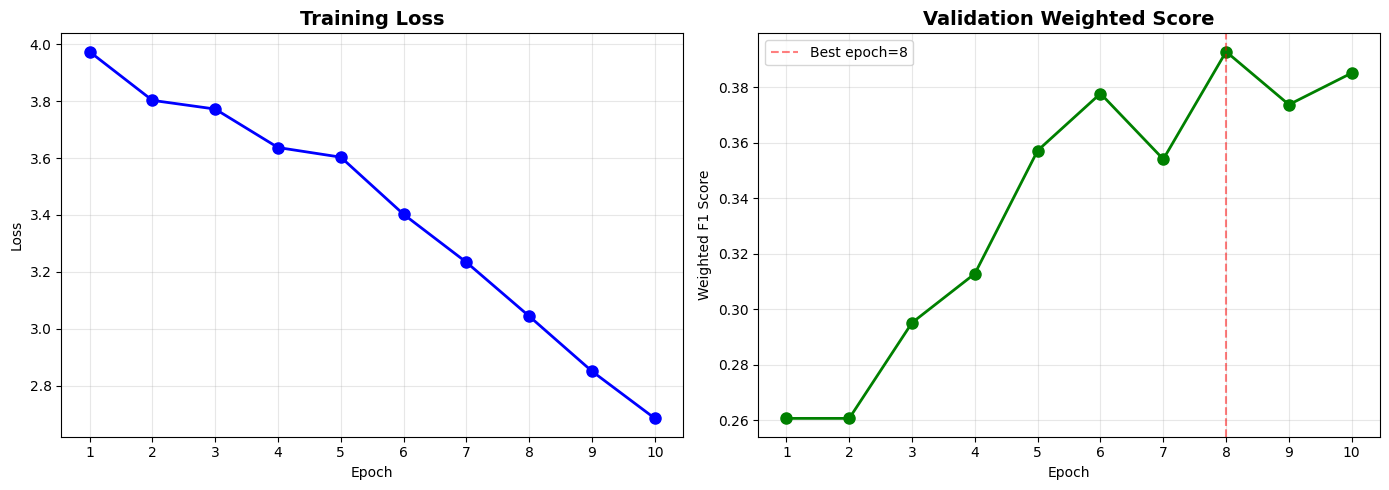

In [ ]:
# 繪製訓練曲線
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history["loss"], 'b-o', linewidth=2, markersize=8)
axes[0].set_title("Training Loss", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(epochs_range)

axes[1].plot(epochs_range, history["weighted_score"], 'g-o', linewidth=2, markersize=8)
axes[1].set_title("Validation Weighted Score", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Weighted F1 Score")
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(epochs_range)

# 標記最佳點
best_epoch = history["weighted_score"].index(max(history["weighted_score"])) + 1
axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best epoch={best_epoch}')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curve.png", dpi=150, bbox_inches='tight')
plt.show()

---

## Step 9: 最終評估與結果分析

訓練完成後，載入最佳模型並進行詳細的結果分析。

In [ ]:
# ============================================================
# 3-Fold 集成預測與最終評估 (Out-of-Fold 評估)
# ============================================================
# 解碼整體 OOF 集成預測結果
final_predictions = []
for i in range(len(all_data)):
    pred = {}
    for field in EVAL_FIELDS:
        # 取得多折概率集成後的最高分類標籤
        pred_id = oof_probabilities[field][i].argmax()
        pred[field] = id2label[field][pred_id]
    final_predictions.append(pred)

# 最終評估結果
final_results = {}
weighted_score = 0.0

for field, labels in EVAL_FIELDS.items():
    y_true = [item[field] for item in all_data]
    y_pred = [item[field] for item in final_predictions]

    macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)
    report   = classification_report(y_true, y_pred, labels=labels, zero_division=0)

    weight = FIELD_WEIGHTS.get(field, 0)
    weighted_score += macro_f1 * weight

    final_results[field] = {
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "report": report,
        "weight": weight
    }

final_results["final_weighted_score"] = weighted_score

print(f"\n{'=' * 60}")
print(f"最終 3-Fold 集成評估結果 (全資料集 OOF 評估)")
print(f"{'=' * 60}")

for field in EVAL_FIELDS:
    r = final_results[field]
    print(f"\n--- {field} (權重: {r['weight']}) ---")
    print(r["report"])
    print(f"  Macro F1: {r['macro_f1']:.4f}")
    print(f"  Micro F1: {r['micro_f1']:.4f}")

print(f"\n{'=' * 60}")
print(f"最終集成加權分數: {final_results['final_weighted_score']:.5f}")
print(f"{'=' * 60}")

In [ ]:
# 視覺化各欄位的 F1 分數 (集成優化版)
fields = list(EVAL_FIELDS.keys())
macro_f1s = [final_results[f]["macro_f1"] for f in fields]
micro_f1s = [final_results[f]["micro_f1"] for f in fields]
weights   = [FIELD_WEIGHTS[f] for f in fields]

x = range(len(fields))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar([i - width/2 for i in x], macro_f1s, width, label='Macro F1', color='darkblue', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], micro_f1s, width, label='Micro F1',  color='orange',     alpha=0.8)

# 加上分數標籤
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel("Task label")
ax.set_ylabel("F1 Score")
ax.set_title(f"F1 Score by Task (Optimized RoBERTa-large Ensemble)\nFinal Weighted Score: {final_results['final_weighted_score']:.5f}", fontsize=14, fontweight='bold')
ax.set_xticks(list(x))
ax.set_xticklabels([f"{f}\n(w={w})" for f, w in zip(fields, weights)], fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(final_results["final_weighted_score"], color='green', linestyle='--',
           linewidth=2, label=f"Weighted Score={final_results['final_weighted_score']:.4f}")
ax.legend()

plt.tight_layout()
plt.savefig("optimized_f1_scores.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 儲存集成預測結果
OUTPUT_PATH = "prediction.json"

output_data = []
for orig, pred in zip(all_data, final_predictions):
    item = dict(orig)   # 複製原始資料
    item.update(pred)   # 覆蓋預測欄位
    output_data.append(item)

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(output_data, f, ensure_ascii=False, indent=2)

print(f"✅ 集成預測結果已儲存至: {OUTPUT_PATH}")
print(f"   共 {len(output_data)} 筆")

# 顯示前3筆預測結果
print("\n📋 前3筆預測結果：")
for i, item in enumerate(output_data[:3]):
    print(f"\n--- 第{i+1}筆 (ID: {item.get('id', 'N/A')}) ---")
    for field in EVAL_FIELDS:
        print(f"  {field}: {item[field]}")

---

## Step 10: 進階改進方向

恭喜你完成了基礎版本！以下是幾個可以進一步提升分數的方向：

### 1. 加入 Dropout 防止過擬合
```python
self.dropout = nn.Dropout(0.1)
pooled = self.dropout(outputs.pooler_output)
```

### 2. 損失加權（針對類別不均衡）
```python
# 給少數類別更高的損失權重
criterion = nn.CrossEntropyLoss(weight=class_weights)
```

### 3. 資料增強
- 同義詞替換
- 回譯（中→英→中）
- 隨機遮罩

### 4. 集成學習（Ensemble）
```python
# 訓練多個模型，取預測結果的多數票
from collections import Counter
ensemble_pred = Counter([model1_pred, model2_pred, model3_pred]).most_common(1)[0][0]
```

### 5. 調整超參數
- 增加 Epochs（10-15）
- 調整 Learning Rate（1e-5 ~ 5e-5）
- 增大 MAX_LEN（512）
- 嘗試不同 BATCH_SIZE

---
## 工作坊總結

今天我們學習了：
1. ESG 承諾驗證任務的定義
2. 使用 EDA 分析資料分佈
3. 實作 PyTorch Dataset & DataLoader
4. 設計 Multi-Task BERT 模型架構
5. 完整的訓練、評估、預測流程
6. 使用加權 Macro F1 評分

**祝大家在比賽中取得好成績！**